C:\Users\janav\AppData\Local\Temp\ipykernel_39100\3098109312.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("models/best_model.pt", map_location=DEV

0


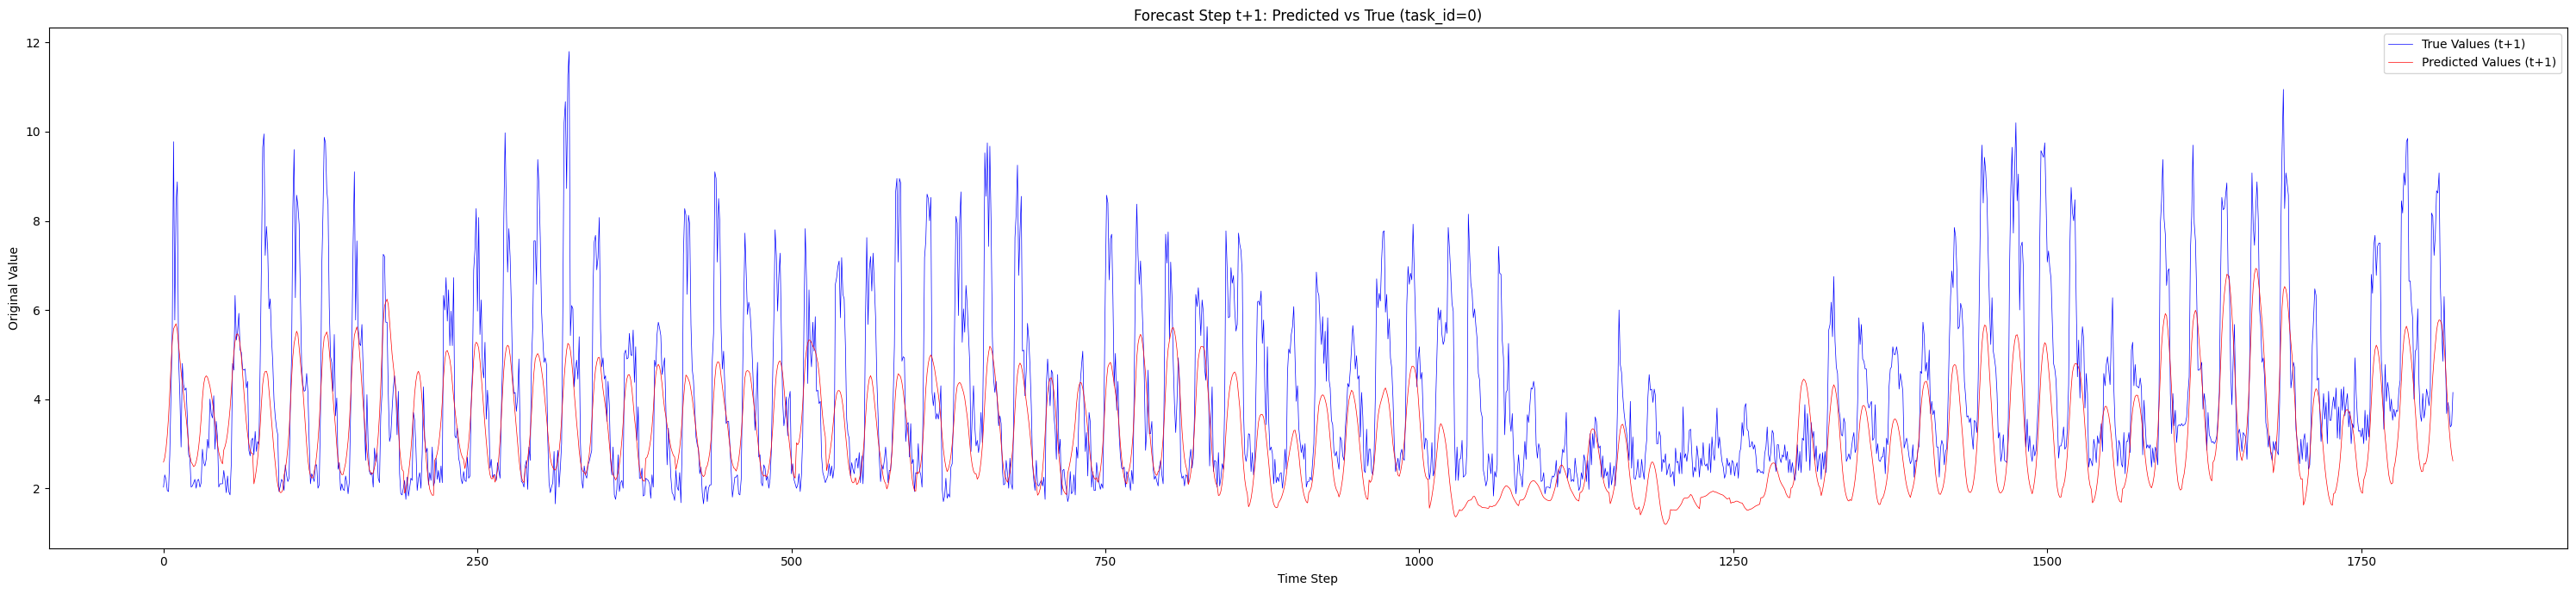

1


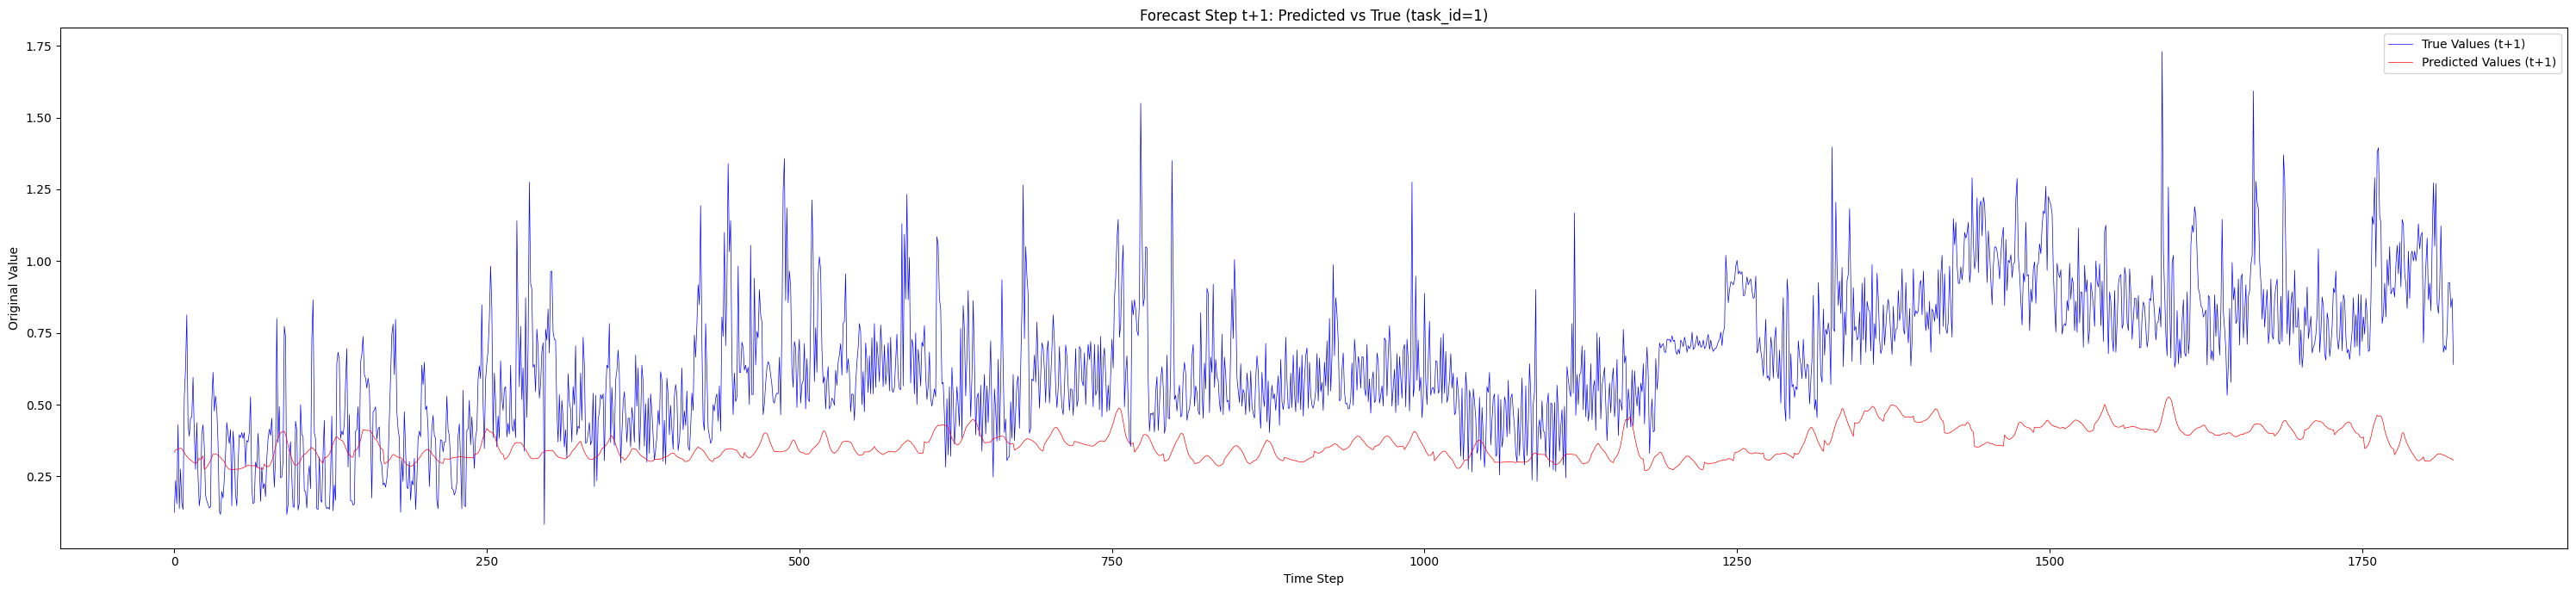

2


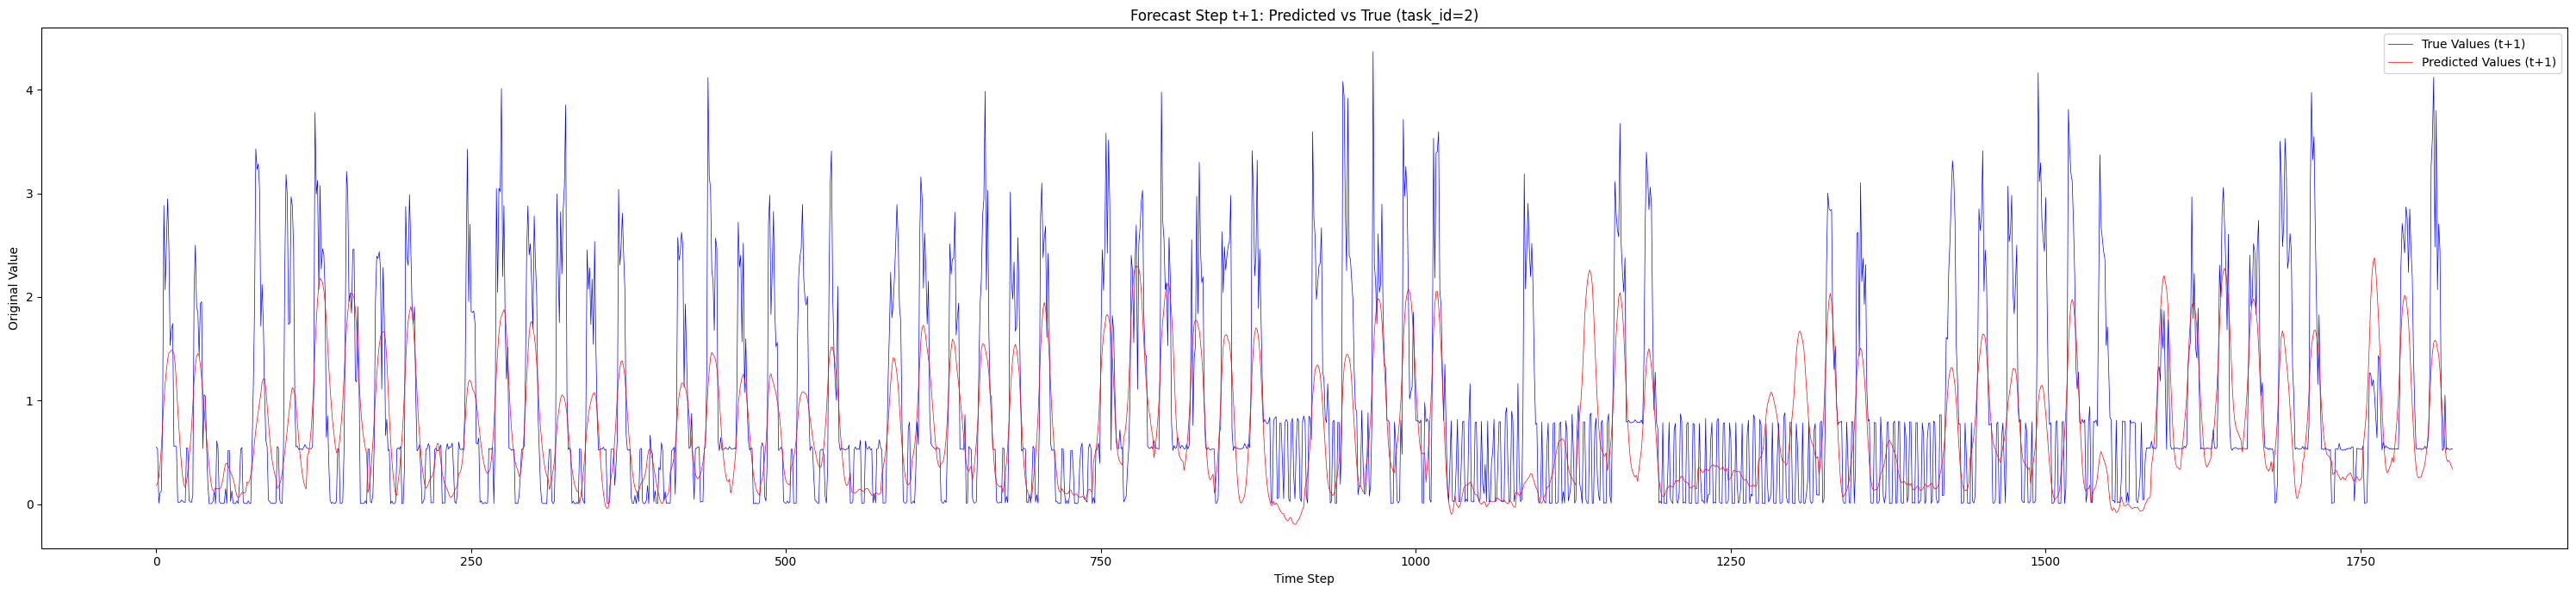

3


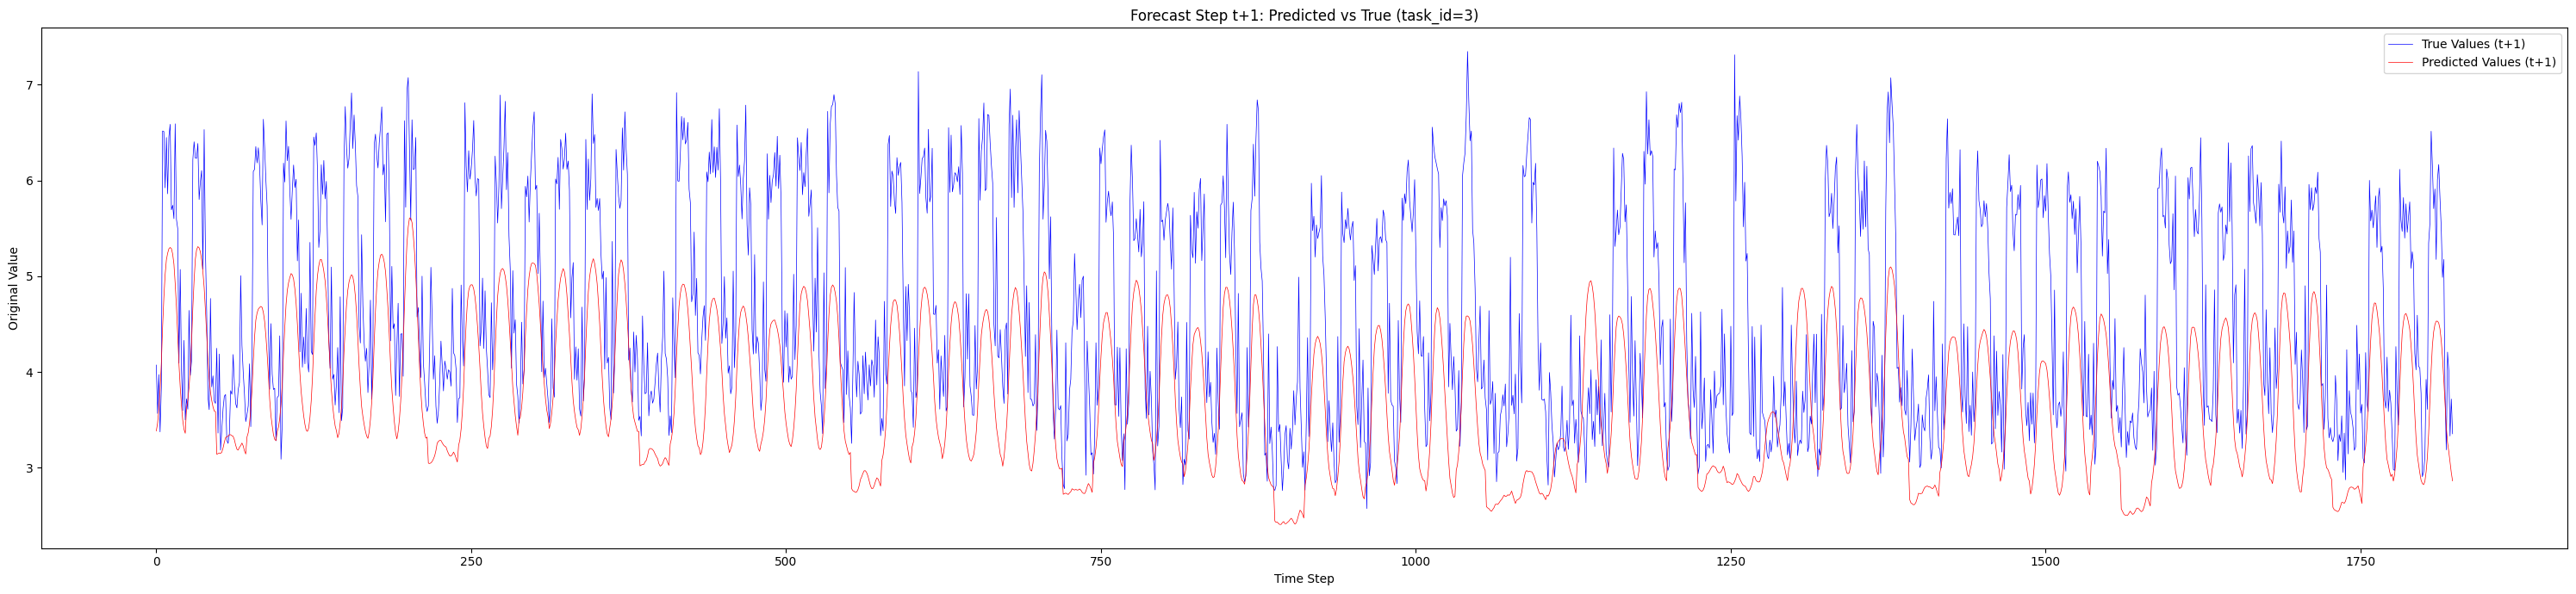

4


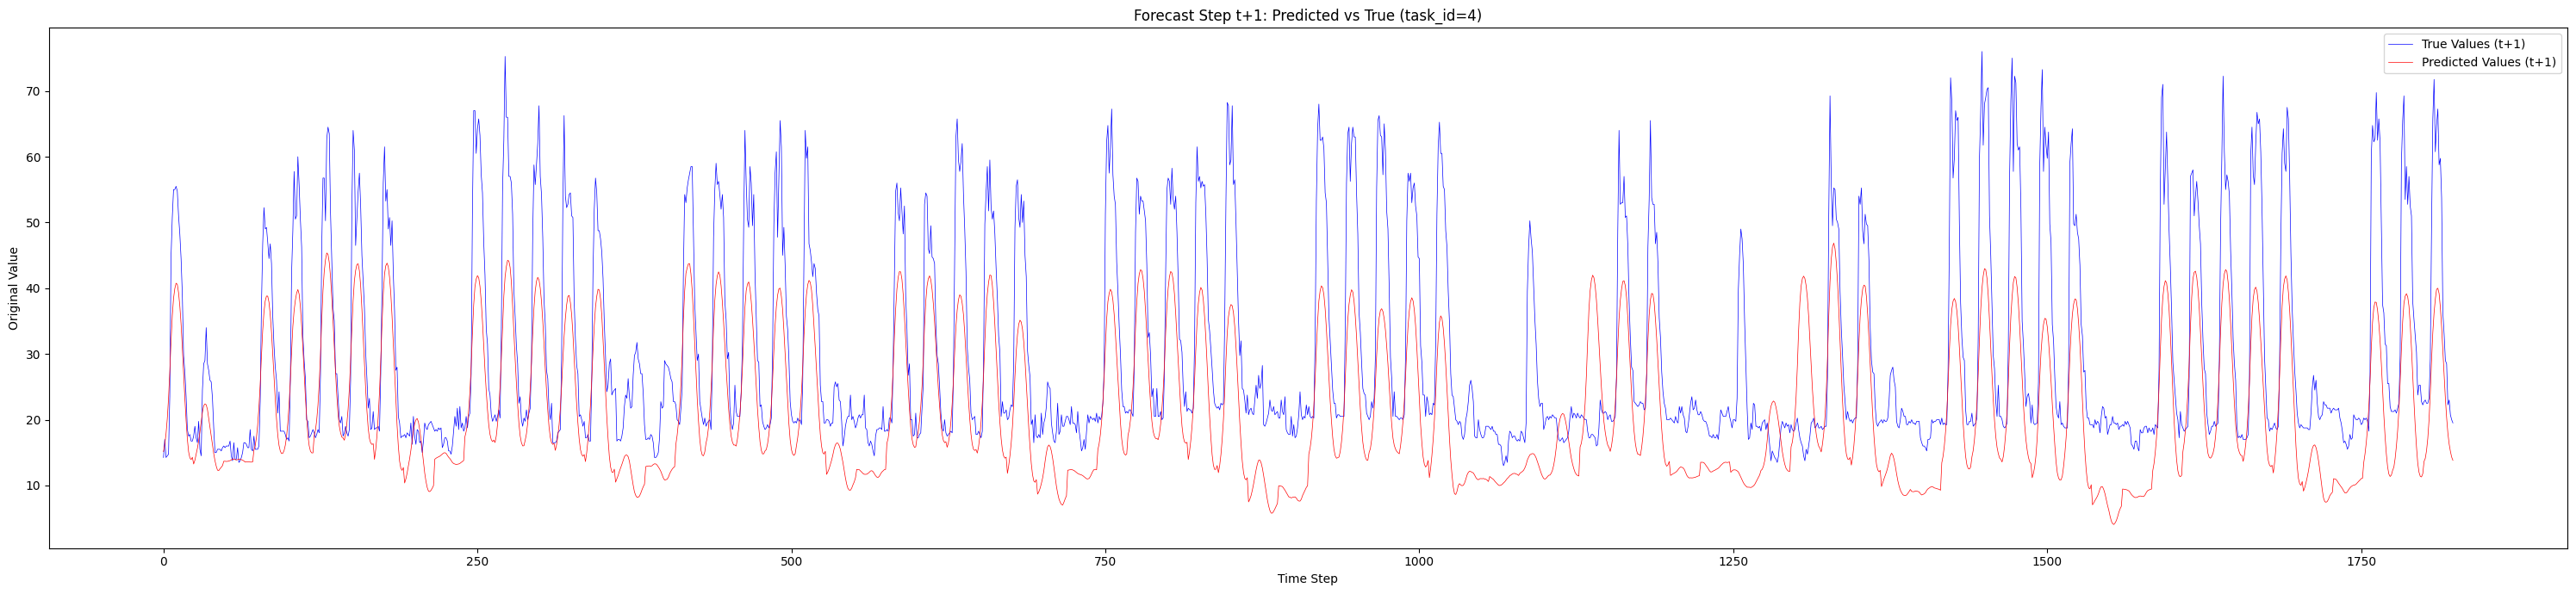

5


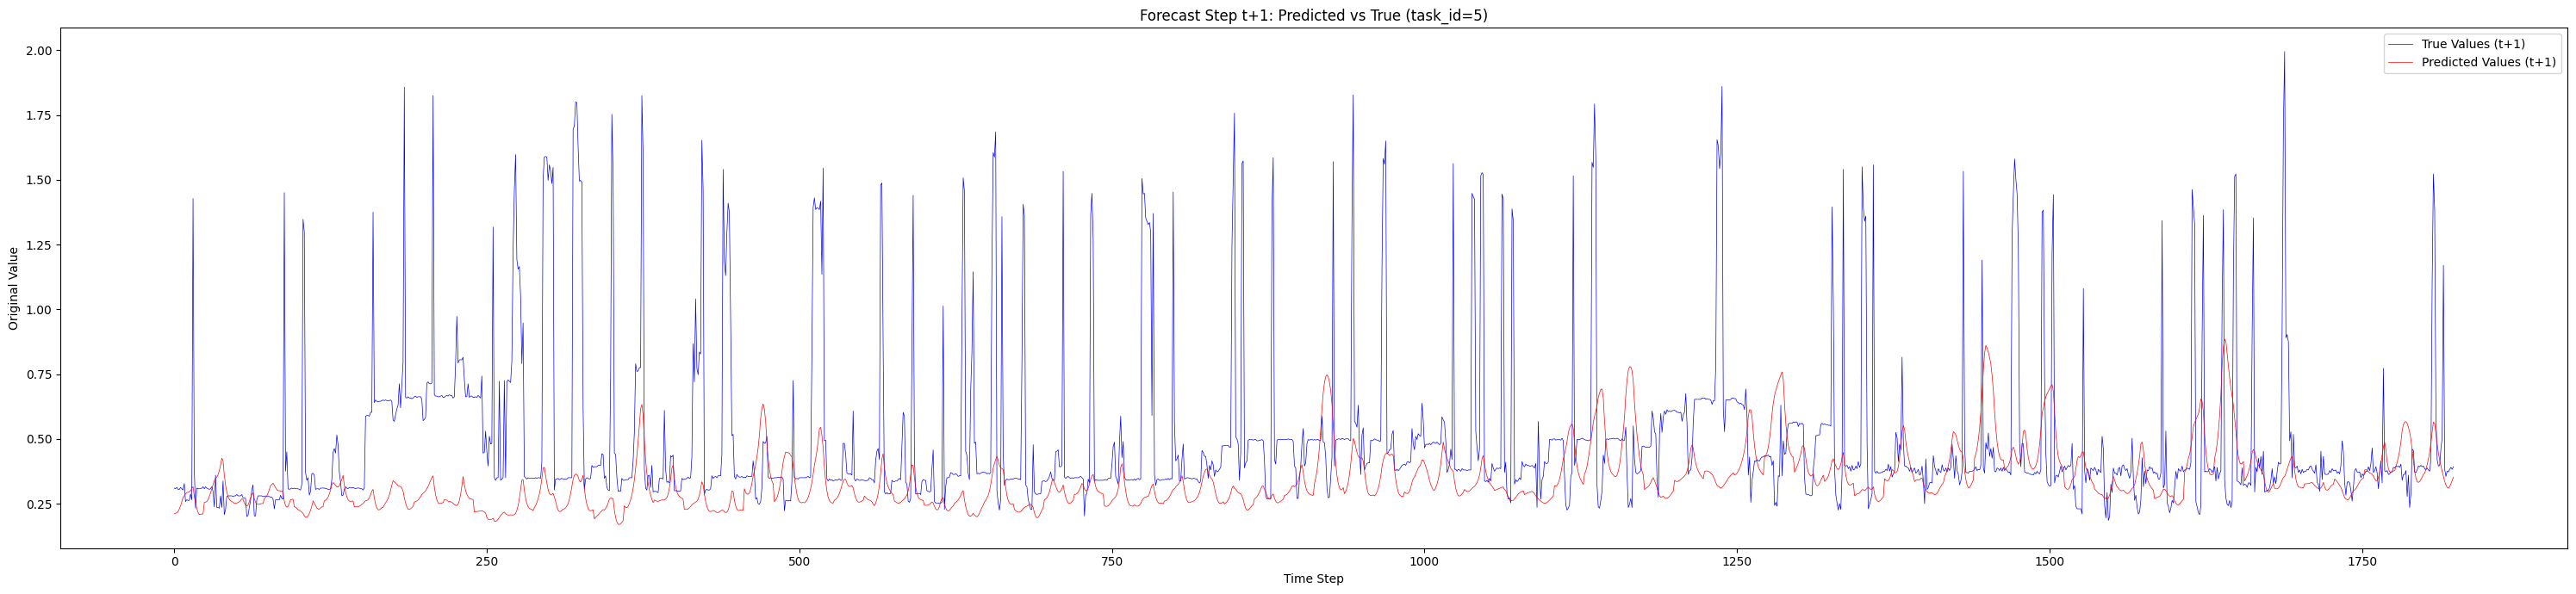

6


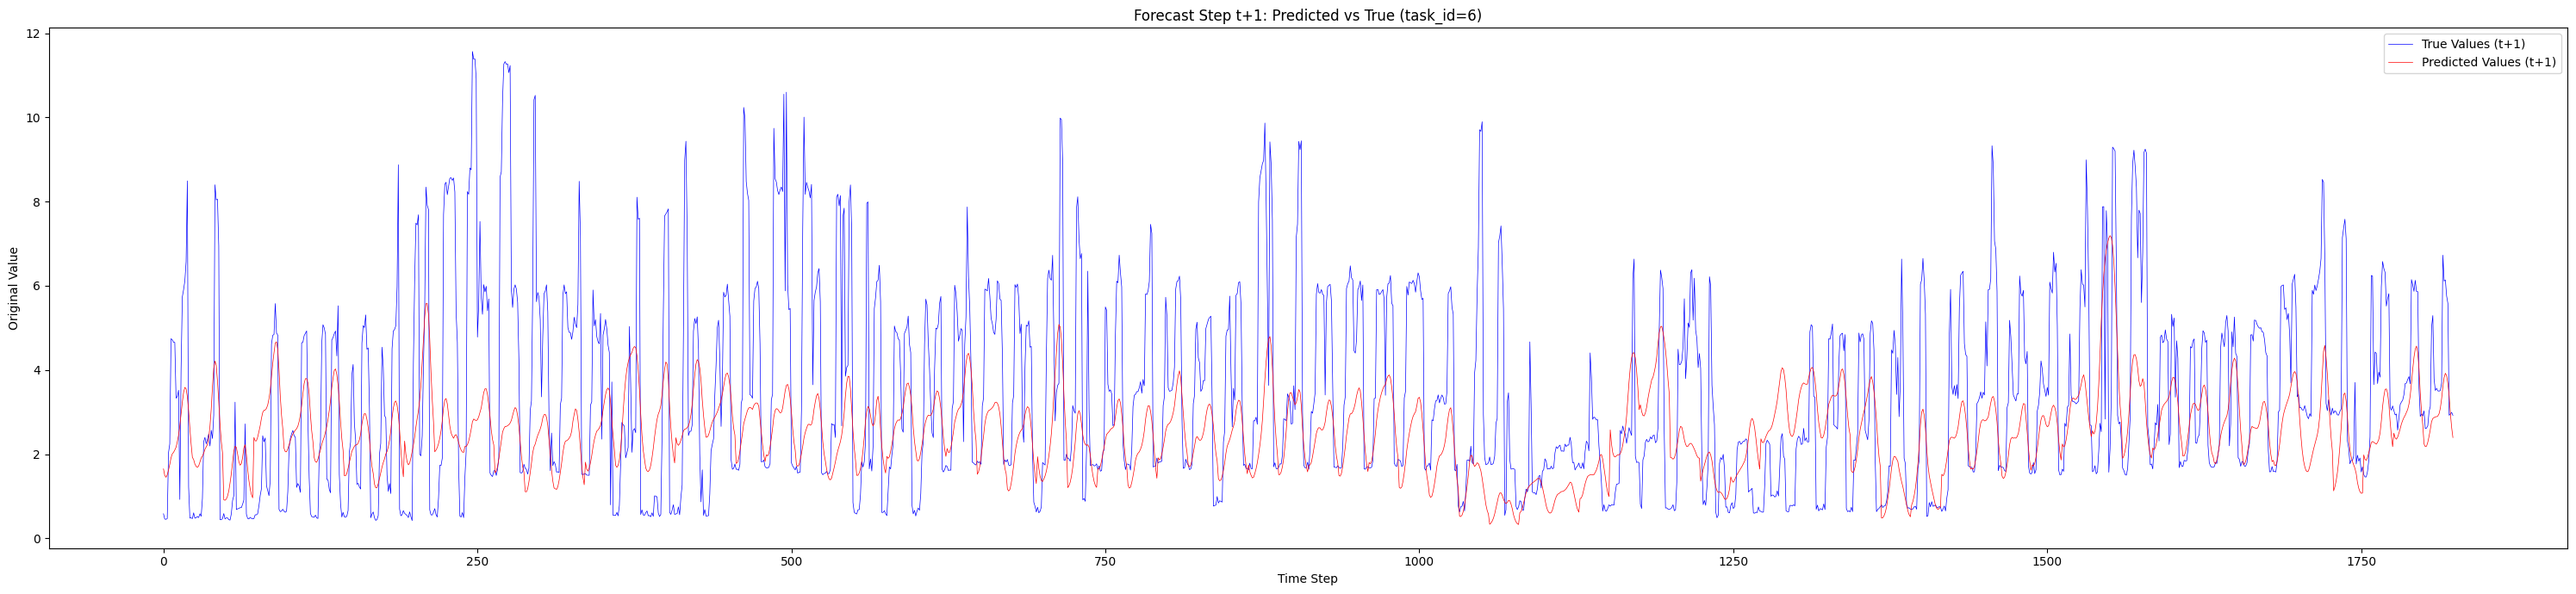

7


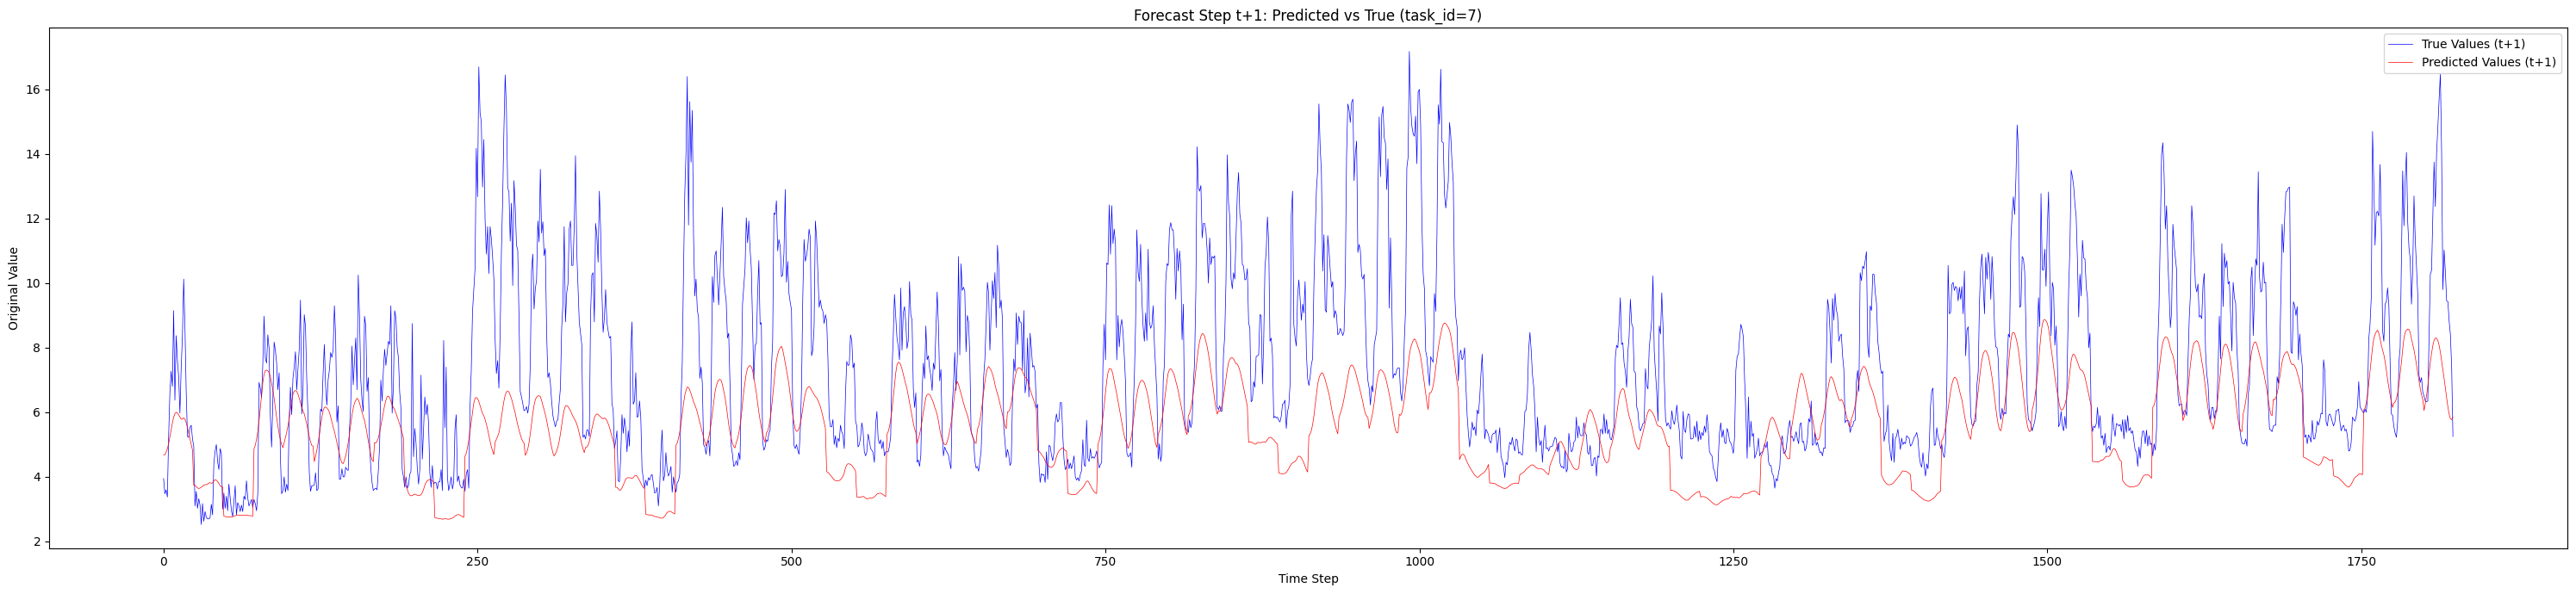

In [9]:
from util import fit_scalers_per_task, inverse_transform_per_task
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from data import load_and_preprocess, split_by_task

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def plot_data(y_true, y_pred, task_id):
    plt.figure(figsize=(30, 7))
    plt.plot(y_true, color='blue', linewidth=0.5, label='True Values (t+1)')
    plt.plot(y_pred, color='red', linewidth=0.5, label='Predicted Values (t+1)')
    plt.title(f"Forecast Step t+1: Predicted vs True (task_id={task_id})")
    plt.xlabel("Time Step")
    plt.ylabel("Original Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------- Load data and refit scalers ----------
Xdf, ydf = load_and_preprocess("data/merged.csv")
X_train_df, y_train_df, X_val_df, y_val_df, X_test_df, y_test_df = split_by_task(
    Xdf, ydf, val_ratio=0.1, test_ratio=0.3
)
train_task_ids = X_train_df["task_id"].values

# Fit scalers PER TASK ONLY ON TRAIN SPLIT
scalers, y_train_scaled = fit_scalers_per_task(y_train_df.values, train_task_ids)

# ------------- Load model ---------------
model = torch.load("models/best_model.pt", map_location=DEVICE)
model.eval()

kernel_features = ["time", "day_of_year", "day_type"]

# ------------- Predict and inverse transform per task -------------
for task_id in sorted(X_test_df["task_id"].unique()):
    print(task_id)
    idx_task = X_test_df["task_id"] == task_id
    X_task = X_test_df.loc[idx_task, kernel_features].reset_index(drop=True)
    y_task = y_test_df.loc[idx_task].reset_index(drop=True)
    n = len(X_task)
    n_forecast = int(n * 0.3)
    start_idx = n - n_forecast

    # Model input
    X_pred = torch.tensor(X_task.iloc[start_idx:].values, dtype=torch.float32, device=DEVICE)
    task_ids_pred = torch.full((n_forecast,), task_id, dtype=torch.long, device=DEVICE)

    # Scaled ground truth
    y_true = y_task.iloc[start_idx:].values

    # Model prediction (still scaled)
    with torch.no_grad():
        G_pred = model.shared_basis(X_pred)
        y_pred_scaled = model.predict_with_basis(G_pred, task_ids_pred).cpu().numpy().flatten()

    # Inverse transform (to original kWh, per task)
    task_ids_np = np.full(n_forecast, task_id)
    y_pred = inverse_transform_per_task(y_pred_scaled, task_ids_np, scalers)

    plot_data(y_true, y_pred, task_id)
